# Import Pillow for importing image and numpy for Numeric Operation

In [1]:
import PIL.Image as Image
import numpy as np
import matplotlib.pyplot as plt

# Import The Image

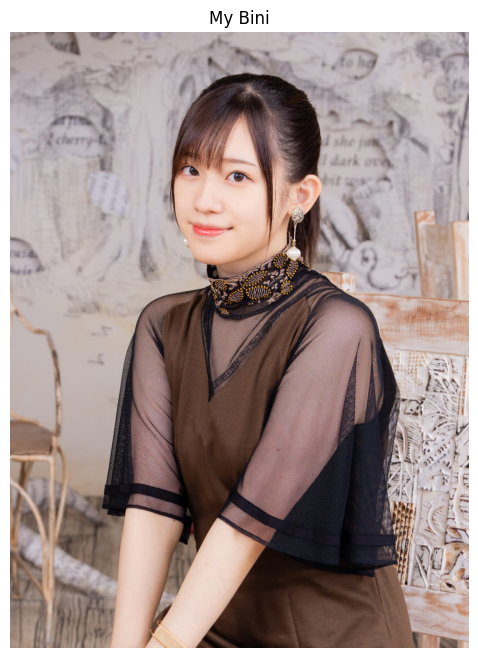

In [2]:
colored = Image.open("RieTakahashi.jpg")
colored_array = np.array(colored)

plt.figure(figsize=(8, 8))
plt.title("My Bini")
plt.imshow(colored_array)
plt.axis("off")
plt.show()

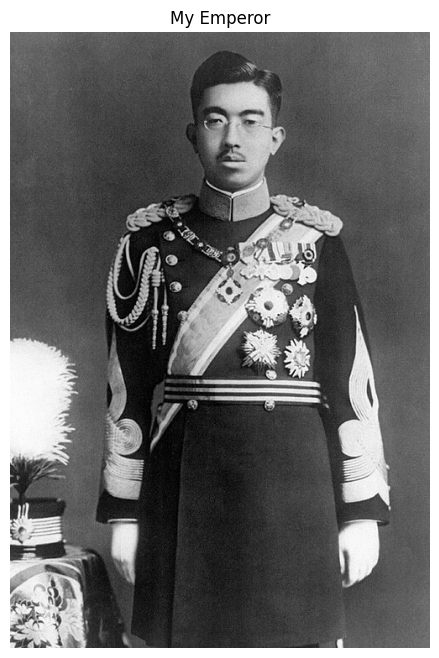

In [3]:
black_and_white = Image.open("でんか.jpg")
black_and_white_array = np.array(black_and_white)

plt.figure(figsize=(8, 8))
plt.title("My Emperor")
plt.imshow(black_and_white_array, cmap="gray")
plt.axis("off")
plt.show()

# Brightness Adjustment

In [4]:
def adjust_brightness(image:np.array, quantity:int) -> np.array:
    """
    Adjust the brightness of an image by adding a specified quantity to each pixel value.

    Parameters:
    image (np.array): The input image as a NumPy array.
    quantity (int): The amount to adjust the brightness. Positive values increase brightness, while negative values decrease it.

    Returns:
    np.array: The brightness-adjusted image as a NumPy array.
    """
    
    img_copy = image.copy().astype(np.int16)  # Use int16 to prevent overflow during addition
    
    # Ensure the quantity is within the valid range
    if not (-255 <= quantity <= 255):
        raise ValueError("Quantity must be between -255 and 255.")
    
    # Adjust brightness by adding the quantity to each pixel value
    adjusted_image = img_copy + quantity
    
    # Clip the pixel values to be within the valid range [0, 255]
    adjusted_image = np.clip(adjusted_image, 0, 255)
    
    return adjusted_image.astype(np.uint8)

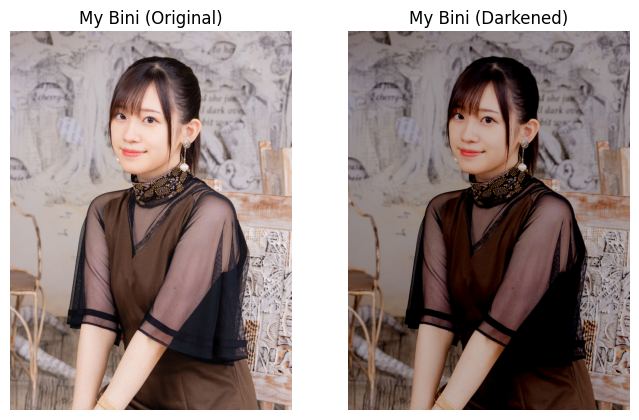

In [5]:
colored_array_bright = adjust_brightness(colored_array, -50)
plt.figure(figsize=(8, 8))

plt.subplot(1, 2, 1)
plt.title("My Bini (Original)")
plt.imshow(colored_array)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("My Bini (Darkened)")
plt.imshow(colored_array_bright)
plt.axis("off")
plt.show()

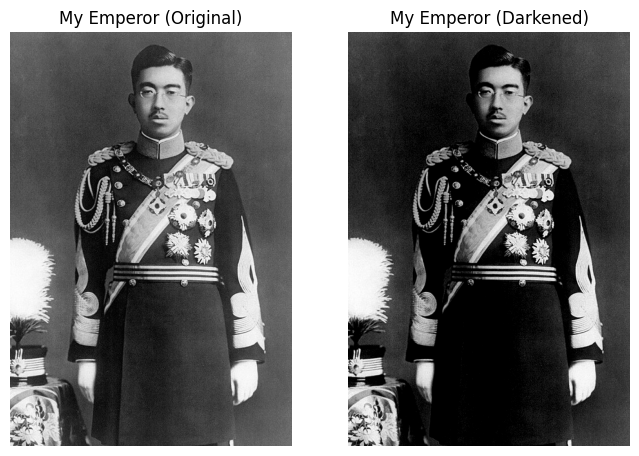

In [6]:
black_and_white_dark = adjust_brightness(black_and_white_array, -50)
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.title("My Emperor (Original)")
plt.imshow(black_and_white_array, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("My Emperor (Darkened)")
plt.imshow(black_and_white_dark, cmap="gray")
plt.axis("off")
plt.show()


# Contrast Adjustment

In [7]:
def contrast_adjust(img: np.array, factor: float) -> np.array:
    """
    Adjust the contrast of an image by applying a contrast adjustment formula.

    Parameters:
    image (np.array): The input image as a NumPy array.
    factor (float): The factor by which to adjust the contrast.

    Returns:
    np.array: The contrast-adjusted image as a NumPy array.
    """
    
    img_copy = img.astype(np.float32)

    if factor <= 0:
        raise ValueError("Factor must be greater than 0.")

    # Apply contrast formula
    adjusted = (img_copy - 128) * factor + 128

    # Clip to valid range
    adjusted = np.clip(adjusted, 0, 255)

    return adjusted.astype(np.uint8)

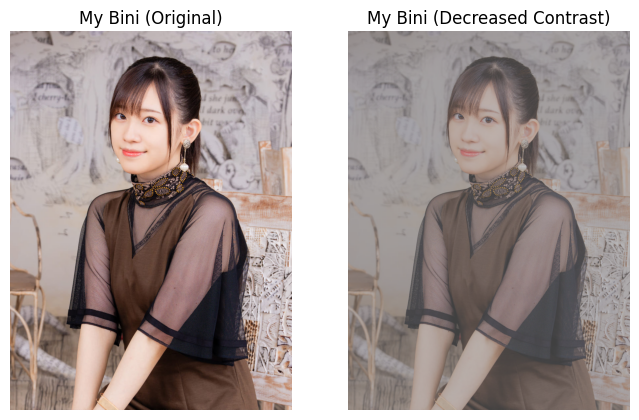

In [8]:
colored_array_contrast = contrast_adjust(colored_array, 0.5)
plt.figure(figsize=(8, 8))

plt.subplot(1, 2, 1)
plt.title("My Bini (Original)")
plt.imshow(colored_array)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("My Bini (Decreased Contrast)")
plt.imshow(colored_array_contrast)
plt.axis("off")
plt.show()

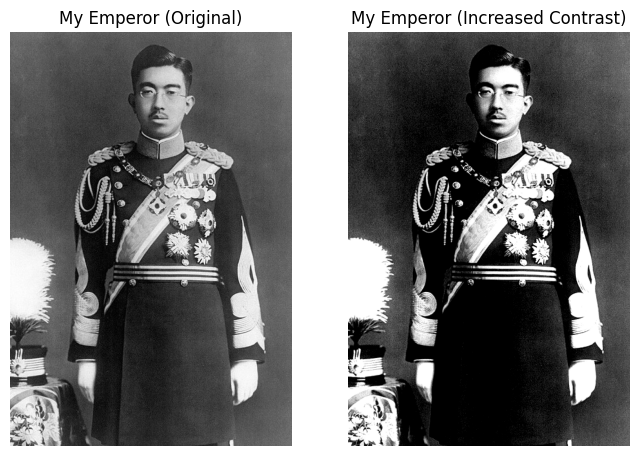

In [9]:
black_and_white_contrast = contrast_adjust(black_and_white_array, 1.7)
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.title("My Emperor (Original)")
plt.imshow(black_and_white_array, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("My Emperor (Increased Contrast)")
plt.imshow(black_and_white_contrast, cmap="gray")
plt.axis("off")
plt.show()


# Thresholding Function

In [10]:
def treshold_adjust(image: np.array, threshold: int) -> np.array:
    """
    Adjust the threshold of a grayscale image by setting pixel values above the threshold to 255 and those below to 0.

    Parameters:
    image (np.array): The input grayscale image as a NumPy array.
    threshold (int): The threshold value to apply.

    Returns:
    np.array: The threshold-adjusted image as a NumPy array.
    """
    
    if not (0 <= threshold <= 255):
        raise ValueError("Threshold must be between 0 and 255.")
    
    # Create a copy of the image to avoid modifying the original
    img_copy = image.copy()
    
    # Apply thresholding
    img_copy[img_copy > threshold] = 255
    img_copy[img_copy <= threshold] = 0
    
    return img_copy.astype(np.uint8)

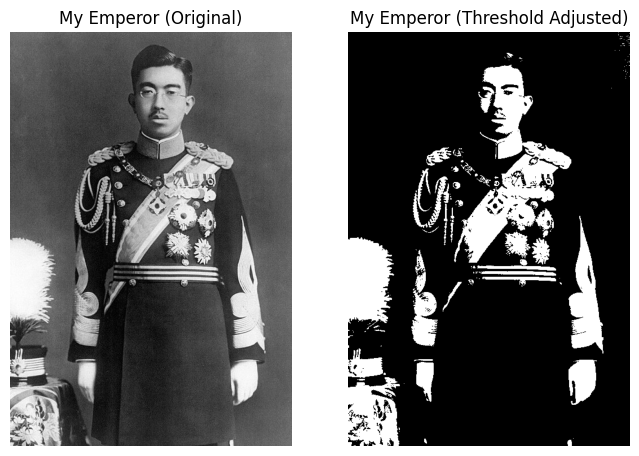

In [11]:
black_and_white_threshold = treshold_adjust(black_and_white_array, 128)
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.title("My Emperor (Original)")
plt.imshow(black_and_white_array, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("My Emperor (Threshold Adjusted)")
plt.imshow(black_and_white_threshold, cmap="gray")
plt.axis("off")
plt.show()

# Transformation using bilinear interpolation

In [12]:
def bilinear_interpolate(image : np.array, x : float, y : float) -> int:
    """
    Adjust the threshold of a grayscale image by setting pixel values above the threshold to 255 and those below to 0.

    Parameters:
    image (np.array): The input grayscale image as a NumPy array.
    threshold (int): The threshold value to apply.

    Returns:
    np.array: The threshold-adjusted image as a NumPy array.
    """

    h, w = image.shape[:2] 
    
    # Determine the coordinates of the four surrounding pixels
    x0 = int(np.floor(x)) 
    x1 = x0 + 1 
    y0 = int(np.floor(y)) 
    y1 = y0 + 1 
    
    # Check if the surrounding pixels are within the image boundaries
    if x0 < 0 or x1 >= w or y0 < 0 or y1 >= h: 
        return 0 
    
    # Get the pixel values of the four surrounding pixels
    Ia = image[y0, x0] 
    Ib = image[y1, x0] 
    Ic = image[y0, x1] 
    Id = image[y1, x1] 
    
    # Calculate the weights for each surrounding pixel
    wa = (x1-x)*(y1-y) 
    wb = (x1-x)*(y-y0) 
    wc = (x-x0)*(y1-y) 
    wd = (x-x0)*(y-y0) 
    
    # Compute the interpolated pixel value
    return wa*Ia + wb*Ib + wc*Ic + wd*Id

In [13]:
def geometric_transform(image: np.array, matrix: np.array) -> np.array:
    """
    do the geometric transformation of an image using a given transformation matrix.

    Parameters:
    image (np.array): The input grayscale image as a NumPy array.
    matrix (np.array): The transformation matrix.

    Returns:
    np.array: The geometrically transformed image as a NumPy array.
    """
    h, w = image.shape[:2]
    
    # output image initialized with zeros
    output = np.zeros_like(image)
    
    # inverse the matrix
    inv_matrix = np.linalg.inv(matrix)
    
    for y in range(h):
        for x in range(w):
            # output pixel (x,y) mapping to input pixel (src_x, src_y)
            src = inv_matrix @ np.array([x, y, 1])
            src_x, src_y = src[0], src[1]
            
            # bilinear interpolation to get the pixel value at (src_x, src_y) and assign it to output[y, x]
            output[y, x] = bilinear_interpolate(image, src_x, src_y)
    
    return output

In [14]:
def translate_image(image:np.array, tx:int, ty:int) -> np.array:
    """
    Translate an image by a specified amount in the x and y directions.

    Parameters:
    image (np.array): The input grayscale image as a NumPy array.
    tx (int): The translation amount in the x direction.
    ty (int): The translation amount in the y direction.

    Returns:
    np.array: The translated image as a NumPy array.
    """
    # Create the translation matrix
    translation_matrix = np.array([[1, 0, tx],
                                   [0, 1, ty],
                                   [0, 0, 1]])
    
    # Apply geometric transformation using the translation matrix
    translated_image = geometric_transform(image, translation_matrix)
    
    return translated_image

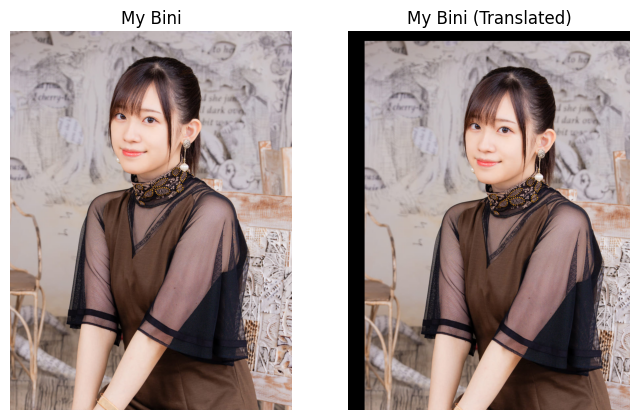

In [15]:
translated_color = translate_image(colored_array, 50, 30)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.title("My Bini")
plt.imshow(colored_array)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("My Bini (Translated)")
plt.imshow(translated_color)
plt.axis("off")
plt.show()

In [16]:
def rotate_centered_image(image: np.array, angle: float) -> np.array:
    """
    Rotate a grayscale image around its center by a specified angle.

    Parameters:
    image (np.array): The input grayscale image as a NumPy array.
    angle (float): The angle in degrees to rotate the image.

    Returns:
    np.array: The rotated image as a NumPy array.
    """
    h, w = image.shape[:2]
    center_x, center_y = w / 2, h / 2
    
    # Convert angle from degrees to radians
    theta = np.radians(angle)
    
    # Create the rotation matrix around the center
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta), center_x * (1 - np.cos(theta)) + center_y * np.sin(theta)],
                                [np.sin(theta),  np.cos(theta), center_y * (1 - np.cos(theta)) - center_x * np.sin(theta)],
                                [0,              0,             1]])
    
    # Apply geometric transformation using the rotation matrix
    rotated_image = geometric_transform(image, rotation_matrix)
    
    return rotated_image

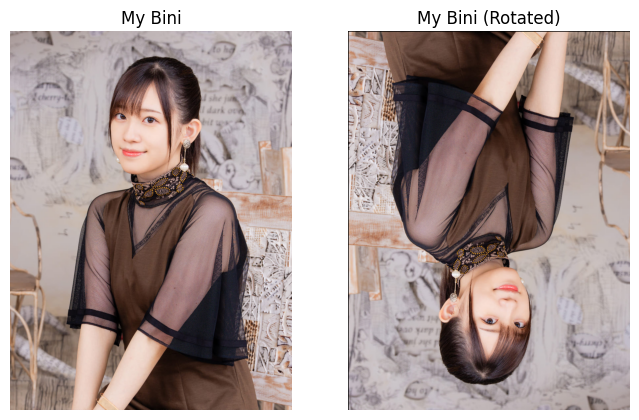

In [17]:
my_bini_rotated = rotate_centered_image(colored_array, 180)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.title("My Bini")
plt.imshow(colored_array)
plt.axis("off") 

plt.subplot(1, 2, 2)
plt.title("My Bini (Rotated)")
plt.imshow(my_bini_rotated)
plt.axis("off")
plt.show()


In [18]:
def scaled_centered_image(image: np.array, scale_x: float, scale_y: float) -> np.array:
    """
    Scale a grayscale image around its center by specified factors in the x and y directions.

    Parameters:
    image (np.array): The input grayscale image as a NumPy array.
    scale_x (float): The scaling factor in the x direction.
    scale_y (float): The scaling factor in the y direction.

    Returns:
    np.array: The scaled image as a NumPy array.
    """
    h, w = image.shape[:2]
    center_x, center_y = w / 2, h / 2
    
    # Create the scaling matrix around the center
    scaling_matrix = np.array([[scale_x, 0, center_x * (1 - scale_x)],
                               [0, scale_y, center_y * (1 - scale_y)],
                               [0, 0, 1]])
    
    # Apply geometric transformation using the scaling matrix
    scaled_image = geometric_transform(image, scaling_matrix)
    
    return scaled_image

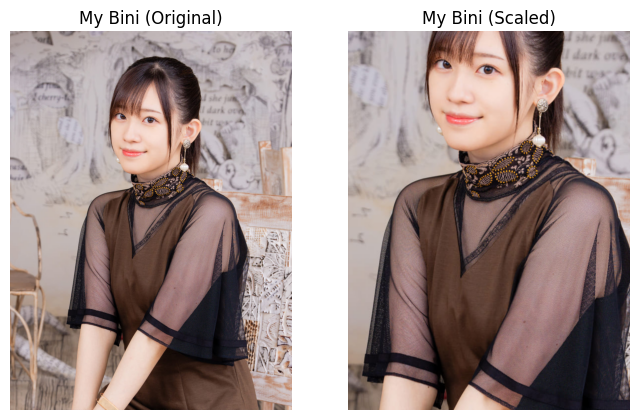

In [19]:
colored_scaled = scaled_centered_image(colored_array, 1.5, 1.5)
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.title("My Bini (Original)")
plt.imshow(colored_array)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("My Bini (Scaled)")
plt.imshow(colored_scaled)
plt.axis("off")
plt.show()